# Example: Simulating a Portfolio with Multiple Asset Geometric Brownian Motion
In this example, we use the multiple asset geometric Brownian motion (MAGBM) model of L5a to simulate a portfolio through calendar year 2025. We estimate the model from the 2014 to 2024 training data, generate many correlated price paths, compute the buy-and-hold wealth of a chosen allocation on every path, and compare the simulated wealth distribution with what actually happened in 2025 and with an index fund. We then evaluate the portfolio the way L4b evaluated a single trade: through its scaled net present value and the probability of clearing a target.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Build a multiple asset GBM model from data:__ Estimate the mean growth-rate vector and the growth-rate covariance matrix for a set of firms from the training data, convert the covariance to the GBM covariance rate, factor it, and build the package model with the correct arithmetic drift.
> * __Simulate correlated price paths and buy-and-hold wealth:__ Generate many 2025 sample paths with a shared shock vector per step, verify that the simulated growth rates reproduce the estimated covariance, and compute the wealth path of a chosen allocation on every path with pointwise Monte Carlo prediction bands, next to the realized 2025 path and an index fund.
> * __Evaluate a portfolio with the trade rule:__ Compute the scaled net present value of the portfolio at year end on every path, estimate the probability that the portfolio clears a target together with its Monte Carlo standard error, and locate the realized outcome in the simulated distribution.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [CSV.jl](https://csv.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [Distributions.jl](https://juliastats.org/Distributions.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), and includes the local `src/Compute.jl` file. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data, from which every model parameter is estimated. The __testing__ data, calendar year 2025 (`01-02-2025` until `12-31-2025`), supplies the initial prices for the simulation and the realized path we compare against.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days, and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

### Constants
Let's specify some constants that we will use in our simulations. Check out the comments for details on the constants, their permissible values, units, etc.

In [4]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
W₀ = 1000.0; # initial wealth (units: USD)
number_of_paths = 2000; # number of Monte Carlo sample paths
g_b = 0.041; # benchmark growth rate for the NPV calculation (units: 1/years): we use the risk-free rate at the end of 2024, the natural alternative use of the money
ρ_target = 0.0; # target scaled NPV ρ⋆ for the trade rule (0 means: beat the benchmark)
Random.seed!(5660); # fixed seed so the sample paths, and hence the figures and probabilities below, are reproducible
allocation_case = :GMV; # which allocation to simulate: :GMV (long-only minimum variance), :equal, :single, or :dirichlet

___

## Task 1: Estimate the MAGBM Model from the Training Data
The MAGBM model needs the mean growth-rate vector $\bar{\mathbf{g}}$ and the covariance rate $\mathbf{C}$ of the firms in the portfolio, and a covariance factor $\mathbf{A}$ with $\mathbf{A}\mathbf{A}^{\top}=\mathbf{C}$. We use the same thirteen firms as the min-var example, so that the allocation we simulate below is the one that example computes:

In [5]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # M = 13 firms, the min-var example's universe

Following the L5a covariance example, we check that the firms share the same trading dates in both datasets, build the growth-rate data matrix with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix), estimate $\hat{\mathbf{g}}$ (the sample-mean growth rate of each firm) with [the `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) and $\hat{\mathbf{\Sigma}}_{g}$ with [the `cov(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov), and convert to the covariance rate $\hat{\mathbf{C}}=\Delta{t}\,\hat{\mathbf{\Sigma}}_{g}$ (units: inverse years). We store them in the `ĝ::Array{Float64,1}`, `Σ̂_g::Array{Float64,2}`, and `Ĉ::Array{Float64,2}` variables:

In [6]:
ĝ, Σ̂_g, Ĉ = let
    for ticker ∈ my_list_of_tickers # the growth-rate matrix aligns rows by position, so the dates must agree
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # growth rates g (units: 1/years), N days × M firms
    ĝ = mean(G, dims=1) |> vec; # sample-mean growth rate of each firm, estimates ḡ (units: 1/years)
    Σ̂_g = cov(G, dims=1); # growth-rate covariance Cov(g) (units: 1/years²)
    Ĉ = Δt*Σ̂_g; # GBM covariance rate (units: 1/years)
    (ĝ, Σ̂_g, Ĉ); # return
end;

Now we factor the covariance rate. We use [the `cholesky(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.cholesky) from the [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/) standard library, which returns a factorization object whose `L` field is the lower-triangular factor; we convert it to a plain [Matrix](https://docs.julialang.org/en/v1/base/arrays/#Base.Matrix) and store it in the `A::Array{Float64,2}` variable. Then we check that we can recover $\hat{\mathbf{C}}$ from $\mathbf{A}\mathbf{A}^{\top}$ [using the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) with [the `isapprox(...)` function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox):

In [7]:
A = cholesky(Ĉ).L |> Matrix; # lower-triangular covariance factor, A Aᵀ = Ĉ (units: 1/years^(1/2))
@assert isapprox(A*transpose(A), Ĉ, rtol = 1e-10) # did we get the factorization right? If no error, yes.

Let's look at what we estimated: the mean growth rate, the growth-rate standard deviation $\sigma_{g,i}=\sqrt{\hat{\Sigma}_{g,ii}}$, and the volatility $\hat{\sigma}_{i}=\sqrt{\hat{C}_{ii}}$ for each firm [using the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/), and the correlation matrix as a heatmap [using the `heatmap(...)` function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple):

 -------- --------- --------- ---------
  ticker    g_mean       σ_g         σ̂ 
  String   Float64   Float64   Float64 
 -------- --------- --------- ---------
    AAPL    0.2328     3.723    0.2345
    MSFT    0.2222     3.421    0.2155
    INTC   -0.0228     4.672    0.2943
      MU    0.1266     6.454    0.4066
     AMD     0.312     7.529    0.4743
    NVDA    0.5324     6.169    0.3886
      GS    0.1064     3.898    0.2456
     BAC    0.0897     4.266    0.2687
     WFC      0.04     4.211    0.2653
       C    0.0258     4.518    0.2846
       F   -0.0407     5.101    0.3213
      GM    0.0268     5.102    0.3214
     JNJ     0.041     2.441    0.1537
 -------- --------- --------- ---------


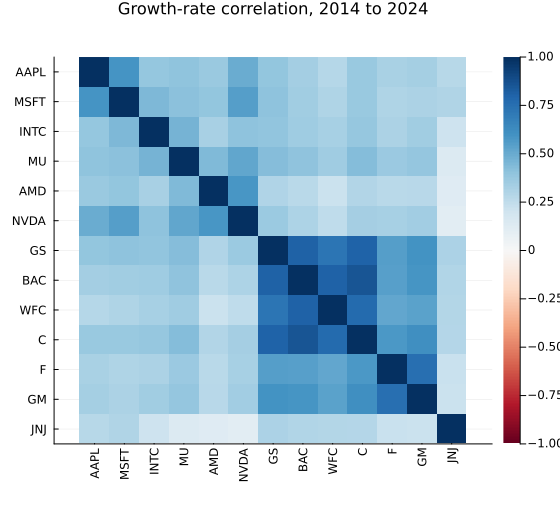

In [8]:
let
    σ_g = sqrt.(diag(Σ̂_g));
    df = DataFrame(ticker = my_list_of_tickers, g_mean = round.(ĝ, digits=4), σ_g = round.(σ_g, digits=3), σ̂ = round.(sqrt.(diag(Ĉ)), digits=4));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    
    ρ̂ = Σ̂_g ./ (σ_g*σ_g'); # correlation matrix
    M = length(my_list_of_tickers);
    heatmap(ρ̂, xticks = (1:M, my_list_of_tickers), yticks = (1:M, my_list_of_tickers), xrotation = 90,
        color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "Growth-rate correlation, 2014 to 2024", titlefontsize = 11, size = (560, 520))
end

The banks move together most strongly, the semiconductor firms with each other, and the health-care firm only weakly with anything. The shared shock vector in the simulation is what carries that structure into the sample paths.
___

## Task 2: Simulate Correlated Price Paths Through 2025
The package implements the MAGBM one-step transition of L5a in [the `MyMultipleAssetGeometricBrownianMotionEquityModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyMultipleAssetGeometricBrownianMotionEquityModel), whose fields are the __arithmetic__ price-SDE drift vector $\boldsymbol{\mu}$ and the covariance factor $\mathbf{A}$; internally it applies the half-variance correction and advances each asset by $S_{i}(t+\Delta{t})=S_{i}(t)\exp[(\mu_{i}-C_{ii}/2)\Delta{t}+\sqrt{\Delta{t}}(\mathbf{A}\mathbf{Z})_{i}]$ with a fresh $\mathbf{Z}$ at every step. Because we estimated the mean growth rate $\hat{\mathbf{g}}$, we must hand the model $\hat{\boldsymbol{\mu}}=\hat{\mathbf{g}}+\tfrac{1}{2}\operatorname{diag}(\hat{\mathbf{C}})$ so that the simulated mean growth rate is $\hat{\mathbf{g}}$. We build the model [using the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMultipleAssetGeometricBrownianMotionEquityModel},%20NamedTuple}) and store it in the `model::MyMultipleAssetGeometricBrownianMotionEquityModel` variable:

In [9]:
model = let
    μ̂ = ĝ + 0.5*diag(Ĉ); # arithmetic GBM drift μ = ḡ + C_ii/2, so the simulated mean growth rate is ĝ
    build(MyMultipleAssetGeometricBrownianMotionEquityModel, (
        μ = μ̂, # arithmetic price-SDE drift vector (units: 1/years)
        A = A  # covariance factor, A Aᵀ = Ĉ
    ));
end;

The simulation starts at the first 2025 price of each firm (the volume-weighted average price on the first trading day of 2025) and runs for the number of trading days actually in the 2025 data. We collect the initial prices in the `S₀::Array{Float64,1}` variable and the 2025 price matrix (rows are trading days, columns are firms) in the `prices_2025::Array{Float64,2}` variable, and read the number of trading days into `N_2025::Int64`:

In [10]:
prices_2025, S₀, N_2025 = let
    N = nrow(dataset_2025["AAPL"]); M = length(my_list_of_tickers);
    S = Array{Float64,2}(undef, N, M);
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        S[:,i] = dataset_2025[ticker][:, :volume_weighted_average_price];
    end
    (S, S[1,:], N); # return
end;
println("2025 has $(N_2025) trading days in the data; horizon T = $(round((N_2025-1)*Δt, digits=4)) years")

2025 has 250 trading days in the data; horizon T = 0.9881 years


Now we generate the sample paths [using the `sample(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyMultipleAssetGeometricBrownianMotionEquityModel,%20NamedTuple}). We pass the initial prices, the start time `T₁ = 0`, the stop time `T₂` (so that the number of rows equals the number of 2025 trading days), and the time step; the function returns a dictionary with one matrix per path, time in the first column and the $M$ prices in the remaining columns. We store it in the `simulation_dictionary::Dict{Int64,Array{Float64,2}}` variable:

In [11]:
simulation_dictionary = let
    T₁ = 0.0; T₂ = (N_2025 - 1)*Δt; # N_2025 rows: the initial condition plus N_2025 - 1 steps
    d = VLQuantitativeFinancePackage.sample(model, (Sₒ = S₀, T₁ = T₁, T₂ = T₂, Δt = Δt), number_of_paths = number_of_paths);
    @assert size(d[1], 1) == N_2025 # one row per 2025 trading day
    d; # return
end;

Before we use the paths, let's check that the simulation reproduces what we asked for. Pooling the one-step growth rates $g_{i}=\ln(S_{i}(t+\Delta{t})/S_{i}(t))/\Delta{t}$ over every step of every path gives a large sample whose mean should be close to $\hat{\mathbf{g}}$ and whose covariance should be close to $\hat{\mathbf{\Sigma}}_{g}$ (the L5a scaling rule, $\text{Cov}(\mathbf{g})=\mathbf{C}/\Delta{t}$). We report the largest relative error of the covariance entries and the mean-growth differences, which should be small but not zero (Monte Carlo error) [using the `diff(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.diff) for the log price changes:

In [12]:
let
    M = length(my_list_of_tickers);
    G_sim = vcat([diff(log.(simulation_dictionary[k][:, 2:end]), dims=1) ./ Δt for k ∈ 1:number_of_paths]...); # pooled one-step growth rates
    Σ_sim = cov(G_sim, dims=1); ḡ_sim = mean(G_sim, dims=1) |> vec;
    println("Pooled sample size: $(size(G_sim,1)) growth-rate vectors")
    println("Max relative error in Cov(g) entries: $(round(maximum(abs.(Σ_sim .- Σ̂_g) ./ abs.(Σ̂_g)), sigdigits=3))")
    println("Mean growth rate, simulated minus estimated (1/yr): $(round.(ḡ_sim .- ĝ, digits=3))")
end

Pooled sample size: 498000 growth-rate vectors
Max relative error in Cov(g) entries: 0.0158
Mean growth rate, simulated minus estimated (1/yr): [0.008, 0.005, 0.004, 0.007, 0.016, 0.01, 0.005, 0.006, -0.005, 0.002, 0.006, 0.009, 0.005]


The covariance is reproduced to about a percent, and the mean growth rates to a few hundredths per year, which is the Monte Carlo error of averaging half a million noisy growth rates whose standard deviations are several per year. The model is doing what L5a said it would.
___

## Task 3: Buy-and-Hold Wealth of a Chosen Allocation
Now we choose how to split $W_{0}$ across the firms. The default is the __long-only global minimum-variance portfolio__ for these firms, computed with the same package solver the min-var example uses (this is the allocation L5a promised we would simulate); the alternatives are equal weights, a single firm, and a random Dirichlet draw from L5a. Set the `allocation_case` constant above to switch. We store the weight vector in the `w::Array{Float64,1}` variable and check that it lies on the simplex:

In [13]:
w = let
    M = length(my_list_of_tickers);
    if allocation_case == :GMV
        bounds = zeros(M, 2); bounds[:,2] .= 1.0; # 0 ≤ wᵢ ≤ 1
        problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g, μ = ĝ, bounds = bounds, initial = (1/M)*ones(M), R = minimum(ĝ)));
        solution = solve(problem); # long-only minimum-variance weights (target constraint is slack)
        @assert solution["status"] == MathOptInterface.LOCALLY_SOLVED
        w = solution["argmax"];
    elseif allocation_case == :equal
        w = (1/M)*ones(M);
    elseif allocation_case == :single
        w = zeros(M); w[findfirst(==("NVDA"), my_list_of_tickers)] = 1.0; # everything in one firm
    elseif allocation_case == :dirichlet
        w = rand(Dirichlet(ones(M))); # one uniform draw from the simplex (L5a)
    else
        error("Unknown allocation_case = $(allocation_case)")
    end
    @assert all(w .≥ -1e-8) && isapprox(sum(w), 1.0, atol = 1e-6) # long only, fully invested
    w; # return
end;

With the weights, the initial prices, and $W_{0}$, we buy $n_{i}=w_{i}W_{0}/S_{i}(0)$ (fractional) shares of each firm and hold them; we store the share counts in the `shares::Array{Float64,1}` variable. Let's tabulate the allocation:

In [14]:
shares = (w*W₀) ./ S₀; # number of shares of each firm held, nᵢ = wᵢ W₀ / Sᵢ(0) (fractional shares allowed)
let
    df = DataFrame(ticker = my_list_of_tickers, S₀ = round.(S₀, digits=2), w = round.(w, digits=4) .+ 0.0, shares = round.(shares, digits=4) .+ 0.0, dollars = round.(w*W₀, digits=2) .+ 0.0);
    push!(df, (ticker = "total", S₀ = NaN, w = round(sum(w), digits=4), shares = NaN, dollars = round(sum(w*W₀), digits=2)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- ---------
  ticker        S₀         w    shares   dollars 
  String   Float64   Float64   Float64   Float64 
 -------- --------- --------- --------- ---------
    AAPL    244.33    0.0901    0.3689     90.15
    MSFT    419.64    0.1423    0.3392    142.33
    INTC     20.22     0.041    2.0285     41.02
      MU     86.57       0.0       0.0       0.0
     AMD    121.17       0.0       0.0       0.0
    NVDA    137.19       0.0       0.0       0.0
      GS    575.93    0.0236     0.041     23.61
     BAC     44.24       0.0       0.0       0.0
     WFC     70.37    0.0595    0.8451     59.47
       C     70.21       0.0       0.0       0.0
       F      9.75    0.0137    1.4018     13.67
      GM     51.73     0.002    0.0388      2.01
     JNJ    144.36    0.6278    4.3486    627.75
   total       NaN       1.0       NaN    1000.0
 -------- --------- --------- --------- ---------


The buy-and-hold wealth on a path is $W_{t}=\sum_{i}n_{i}S_{i}(t)$ (L5a), and we compute it on every simulated path and on the realized 2025 prices. We store the simulated wealth in the `simulated_wealth::Array{Float64,2}` variable (rows are trading days, columns are paths), the realized wealth in the `actual_wealth::Array{Float64,1}` variable, and the wealth of putting all of $W_{0}$ in the [SPY ETF](https://en.wikipedia.org/wiki/SPDR_S%26P_500) (a proxy for the S&P 500 index) in the `spy_wealth::Array{Float64,1}` variable:

In [15]:
simulated_wealth, actual_wealth, spy_wealth = let
    W_sim = Array{Float64,2}(undef, N_2025, number_of_paths);
    for k ∈ 1:number_of_paths
        W_sim[:,k] = simulation_dictionary[k][:, 2:end]*shares; # Σᵢ nᵢ Sᵢ(t) on path k
    end
    W_actual = prices_2025*shares; # same shares, realized 2025 prices
    spy = dataset_2025["SPY"][:, :volume_weighted_average_price];
    W_spy = W₀*(spy ./ spy[1]);
    (W_sim, W_actual, W_spy); # return
end;

Wealth is a sum of lognormal-like quantities and is not symmetric about its mean, so we summarize the paths with __pointwise quantiles__ rather than mean plus or minus a multiple of the standard deviation [using the `quantile(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.quantile): at each trading day, the 5th, 25th, 50th, 75th, and 95th percentiles of wealth across paths. These are pointwise Monte Carlo prediction bands (each day separately), not a band that a whole path stays inside with the stated probability, and the 50th-percentile curve is a pointwise median, not any one simulated path. `Unhide` the code block below to see how we plotted the bands, the pointwise median, the realized 2025 wealth, and the index fund, all scaled by $W_{0}$:

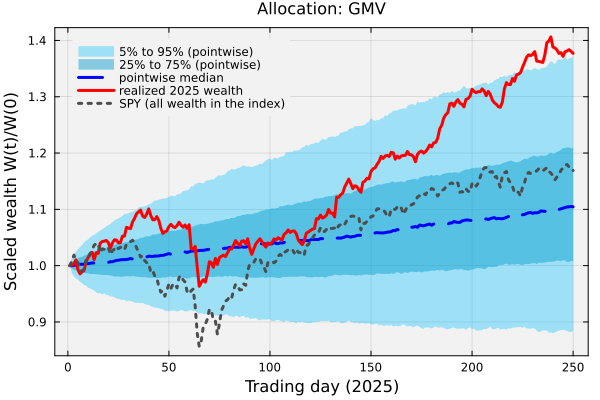

In [16]:
let
    q(p) = [quantile(simulated_wealth[t,:], p) for t ∈ 1:N_2025] ./ W₀;
    q05, q25, q50, q75, q95 = q(0.05), q(0.25), q(0.50), q(0.75), q(0.95);
    days = 1:N_2025;
    plot(days, q95, fillrange = q05, c = :deepskyblue1, alpha = 0.35, lw = 0, label = "5% to 95% (pointwise)")
    plot!(days, q75, fillrange = q25, c = :deepskyblue3, alpha = 0.45, lw = 0, label = "25% to 75% (pointwise)")
    plot!(days, q50, c = :blue, lw = 3, ls = :dash, label = "pointwise median")
    plot!(days, actual_wealth ./ W₀, c = :red, lw = 3, label = "realized 2025 wealth")
    plot!(days, spy_wealth ./ W₀, c = :gray30, lw = 3, ls = :dot, label = "SPY (all wealth in the index)")
    plot!(xlabel = "Trading day (2025)", ylabel = "Scaled wealth W(t)/W(0)", title = "Allocation: $(allocation_case)", titlefontsize = 11,
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

The bands widen as the horizon grows, as expected for a model that accumulates independent shocks (for a single GBM asset the log-price dispersion grows like the square root of time; the pointwise wealth quantiles of a portfolio of correlated lognormals follow no such simple law, but they spread with the horizon). For the default allocation the realized 2025 path spends the second half of the year at or above the upper band: an outcome the model, with these estimates, considered unlikely but not impossible. Whether the realized path stays inside the bands says something about the model (constant parameters estimated on 2014 to 2024) as much as about the allocation; the L5a out-of-sample example made the same point for a single asset. Change `allocation_case` and re-run to see how the bands change with the allocation: a single volatile firm gives wide bands, the minimum-variance portfolio narrow ones.
___

## Task 4: Portfolio NPV and the Trade Rule
In L4b, we judged a single trade by its scaled net present value against a benchmark growth rate $g_{b}$ and asked for the probability of clearing a target $\rho_{\star}$. The same rule applies to a portfolio, with wealth in place of the share position: for a holding period $T$ (here the 2025 horizon, $T=(N-1)\Delta{t}$ years for $N$ trading days), the scaled NPV of buy-and-hold wealth is:
$$
\rho_{T} = \frac{\texttt{NPV}(g_{b},T)}{W_{0}} = \frac{W_{T}}{W_{0}}\,e^{-g_{b}T} - 1
$$
For a single GBM asset, L4b gave $\mathbb{P}(\rho_{T}>\rho_{\star})$ in closed form; a portfolio's $W_{T}$ is a weighted sum of correlated lognormals, which has no closed-form distribution, so we estimate the probability from the sample paths as the fraction of paths that clear the target, with Monte Carlo standard error $\sqrt{\hat{p}(1-\hat{p})/n}$ for $n$ paths. We compute $\rho_{T}$ on every path, store the values in the `ρ_T::Array{Float64,1}` variable, and compute the realized $\rho_{T}$ from the actual 2025 wealth:

In [17]:
ρ_T, ρ_T_actual = let
    T = (N_2025 - 1)*Δt; # holding period (years)
    ρ = (simulated_wealth[end, :] ./ W₀) .* exp(-g_b*T) .- 1.0; # scaled NPV on each path
    ρ_actual = (actual_wealth[end]/W₀)*exp(-g_b*T) - 1.0; # realized scaled NPV
    (ρ, ρ_actual); # return
end;

let
    n = length(ρ_T);
    p̂ = count(ρ_T .> ρ_target)/n; se = sqrt(p̂*(1 - p̂)/n);
    println("P(ρ_T > $(ρ_target)) ≈ $(round(p̂, digits=3)) ± $(round(se, digits=3)) (Monte Carlo standard error, n = $(n) paths)")
    println("Simulated ρ_T: median = $(round(median(ρ_T), digits=3)), 5% = $(round(quantile(ρ_T, 0.05), digits=3)), 95% = $(round(quantile(ρ_T, 0.95), digits=3))")
    println("Realized 2025 ρ_T = $(round(ρ_T_actual, digits=3)); fraction of simulated paths below it: $(round(count(ρ_T .< ρ_T_actual)/n, digits=3))")
end

P(ρ_T > 0.0) ≈ 0.676 ± 0.01 (Monte Carlo standard error, n = 2000 paths)
Simulated ρ_T: median = 0.061, 5% = -0.151, 95% = 0.316
Realized 2025 ρ_T = 0.322; fraction of simulated paths below it: 0.953


Let's look at the whole simulated distribution of $\rho_{T}$ with the target and the realized value marked [using the `histogram(...)` function](https://docs.juliaplots.org/stable/api/#Plots.histogram-Tuple):

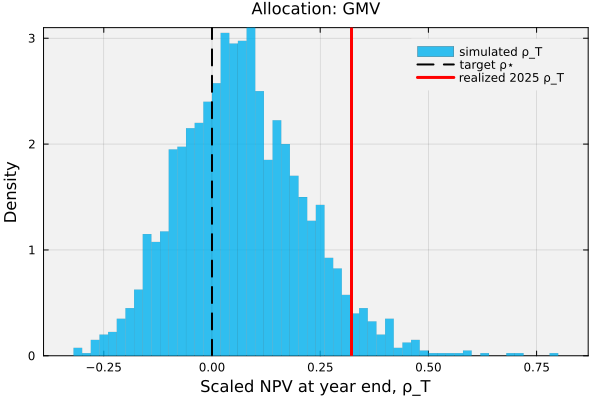

In [18]:
let
    histogram(ρ_T, bins = 60, normalize = :pdf, c = :deepskyblue2, lw = 0, alpha = 0.8, label = "simulated ρ_T")
    vline!([ρ_target], c = :black, lw = 2, ls = :dash, label = "target ρ⋆")
    vline!([ρ_T_actual], c = :red, lw = 3, label = "realized 2025 ρ_T")
    plot!(xlabel = "Scaled NPV at year end, ρ_T", ylabel = "Density", title = "Allocation: $(allocation_case)", titlefontsize = 11,
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent)
end

The distribution is skewed to the right, as a sum of lognormals is, so the median and the mean differ, and the probability of clearing the benchmark is a different number from the expected scaled NPV. Where the realized value lands is one draw from a distribution built on eleven years of estimates; a realized value in the tails is a warning about the estimates or the constant-parameter assumption, not proof of either.
___

## Summary
In this example, we estimated a multiple asset GBM model from the training data, simulated correlated 2025 price paths for a set of firms, computed the buy-and-hold wealth of a minimum-variance allocation on every path with pointwise prediction bands next to the realized path and an index fund, and evaluated the portfolio through the distribution of its scaled net present value.

> __Key Takeaways:__
>
> * **The estimated covariance goes in and comes back out:** Building the model with the arithmetic drift and a covariance factor of the estimated covariance rate, and redrawing a shared shock vector at every step, reproduces the estimated growth-rate mean and covariance in the pooled sample paths to Monte Carlo accuracy.
> * **Wealth bands are quantiles of a skewed distribution:** Buy-and-hold wealth is a weighted sum of correlated lognormal prices, so pointwise quantile bands describe the simulated outcomes correctly where mean plus or minus a multiple of the standard deviation would not, and their width depends on the allocation as much as on the horizon.
> * **A portfolio is judged the way a trade was judged:** The scaled net present value at the horizon and the probability of clearing a target carry over from L4b with wealth in place of the share position, but for a portfolio the probability is a Monte Carlo estimate with a standard error rather than a closed form.

The min-var example computes the allocations this notebook simulates and tests them on the realized 2025 data; the lecture explains why a simulation driven by the same estimates is a scenario engine rather than an independent validation.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___